<div dir="rtl">

# الجريان الأديباتي مع احتكاك في أنبوب ثابت المقطع (جريان فانو)

يتطلب تأمين هواء بتدفق 1000 m³/min عند مخرج أنبوب ثابت المقطع بدرجة حرارة 293 K وضغط 150 kPa. القطر الداخلي 0.3 m والطول 50 m، والجريان أديباتي ومعامل الاحتكاك المتوسط f = 0.005.

المطلوب: رقم ماخ عند المخرج، ضغط الهواء ودرجة حرارته عند المدخل، والتغير الإجمالي في الإنتروبي.

هذه الصفحة على GitHub تعرض الدفتر بنتائجه المحفوظة فقط ولا تشغّله. لتشغيله أو تجربة قيم أخرى افتحه في Google Colab بالضغط على الزر التالي، ثم من قائمة Colab اختر **Runtime ← Run all**. غيّر الأرقام في الخلية الأولى وأعد التشغيل.

</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MohAid/energy-engineering-masters/blob/main/courses/01-advanced-fluid-mechanics/projects/fanno-flow/fanno_flow.ipynb)


In [1]:
# المعطيات، غيرها وأعد التشغيل
Q2 = 1000       # التدفق الحجمي عند المخرج، متر مكعب في الدقيقة
T2 = 293        # درجة الحرارة عند المخرج، كلفن
p2 = 150e3      # الضغط عند المخرج، باسكال
D  = 0.30       # القطر الداخلي، متر
L  = 50         # طول الأنبوب، متر
f  = 0.005      # معامل الاحتكاك المتوسط بتعريف فانينغ

gamma = 1.4     # نسبة الحرارات النوعية
R  = 287        # ثابت الغاز للهواء
cp = gamma*R/(gamma - 1)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# علاقات فانو منسوبة إلى الحالة الصوتية
def fanno_length(M: float | np.ndarray) -> float | np.ndarray:
    # الطول اللابعدي حتى الاختناق
    return (1 - M**2)/(gamma*M**2) \
        + (gamma + 1)/(2*gamma)*np.log((gamma + 1)*M**2/(2 + (gamma - 1)*M**2))

def T_ratio(M: float | np.ndarray) -> float | np.ndarray:
    # نسبة درجة الحرارة
    return (gamma + 1)/(2 + (gamma - 1)*M**2)

def p_ratio(M: float | np.ndarray) -> float | np.ndarray:
    # نسبة الضغط
    return np.sqrt(T_ratio(M))/M

def mach_from_length(fld: float) -> float:
    # استخراج رقم ماخ من الطول اللابعدي بطريقة التنصيف
    lo, hi = 1e-6, 1.0
    for _ in range(100):
        mid = 0.5*(lo + hi)
        if fanno_length(mid) > fld:
            lo = mid
        else:
            hi = mid
    return 0.5*(lo + hi)

In [3]:
# حالة المخرج
A  = np.pi*D**2/4
V2 = Q2/60/A
M2 = V2/np.sqrt(gamma*R*T2)
mdot = p2/(R*T2)*A*V2

assert M2 < 1, "exit Mach number must be subsonic for these inputs"

# حالة المدخل
fld2 = fanno_length(M2)
fld1 = 4*f*L/D + fld2
M1 = mach_from_length(fld1)

p_star = p2/p_ratio(M2)
T_star = T2/T_ratio(M2)
p1 = p_star*p_ratio(M1)
T1 = T_star*T_ratio(M1)

ds = cp*np.log(T2/T1) - R*np.log(p2/p1)
L_max = fld1*D/(4*f)      # الطول الأعظمي قبل الاختناق

print(f"exit Mach number      M2 = {M2:.3f}")
print(f"inlet Mach number     M1 = {M1:.3f}")
print(f"inlet pressure        p1 = {p1/1e3:.1f} kPa")
print(f"inlet temperature     T1 = {T1:.1f} K")
print(f"mass flow rate           = {mdot:.2f} kg/s")
print(f"entropy change        ds = {ds:.1f} J/kg.K   ({ds*mdot:.0f} W/K)")
print(f"max length before choking = {L_max:.1f} m")

exit Mach number      M2 = 0.687
inlet Mach number     M1 = 0.346
inlet pressure        p1 = 308.0 kPa
inlet temperature     T1 = 313.2 K
mass flow rate           = 29.73 kg/s
entropy change        ds = 139.6 J/kg.K   (4149 W/K)
max length before choking = 53.5 m


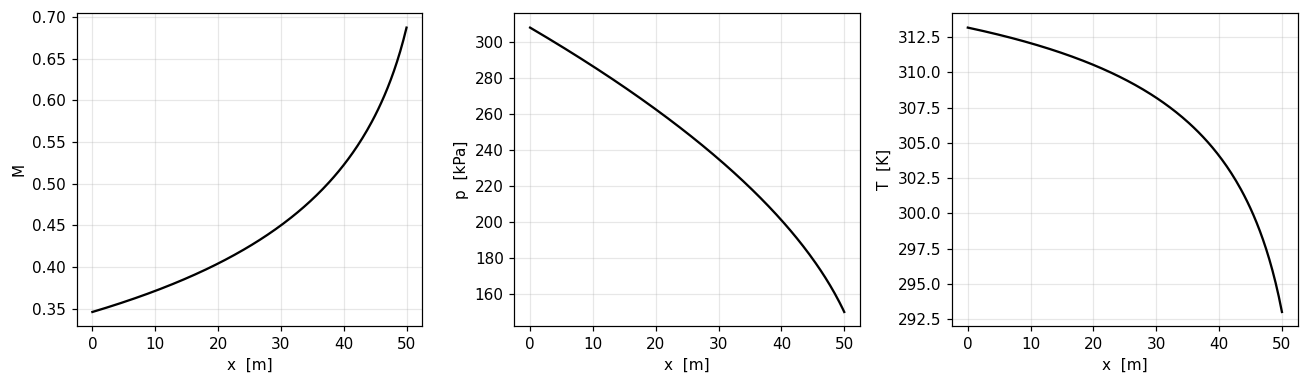

In [4]:
# التغير على طول الأنبوب
x = np.linspace(0, L, 200)
M = np.array([mach_from_length(fld1 - 4*f*xi/D) for xi in x])
p = p_star*p_ratio(M)/1e3
T = T_star*T_ratio(M)

fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].plot(x, M, 'k');  ax[0].set_ylabel('M')
ax[1].plot(x, p, 'k');  ax[1].set_ylabel('p  [kPa]')
ax[2].plot(x, T, 'k');  ax[2].set_ylabel('T  [K]')
for a in ax:
    a.set_xlabel('x  [m]')
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()